# 02 — Modelos Baseline com Rastreamento MLflow

Treina dois modelos de referência com validação cruzada estratificada e registra os experimentos no MLflow.

| Modelo | Propósito |
|---|---|
| `DummyClassifier(strategy='most_frequent')` | Piso mínimo de desempenho |
| `LogisticRegression(class_weight='balanced')` | Baseline linear interpretável |

**Métricas:** AUC-ROC · PR-AUC · F1-Score (threshold = 0.5)  
**CV:** StratifiedKFold, 5 folds, `random_state=42`

In [1]:
import logging
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve

from src.data.loader import load_raw
from src.features.pipeline import split_data
from src.models.baseline import train_all

logging.basicConfig(
    level=logging.INFO,
    format="%(name)s — %(levelname)s — %(message)s",
)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("ROOT:", ROOT)

c:\Users\henri\OneDrive\Documents\Study\fiap26\telecom-churn-mlp\.venv\Lib\site-packages\pandera\_pandas_deprecated.py:143: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


ROOT: c:\Users\henri\OneDrive\Documents\Study\fiap26\telecom-churn-mlp


## 1. Carregamento e Split dos Dados

In [2]:
df = load_raw()
X_train_val, X_test, y_train_val, y_test = split_data(df)

print(f"Treino/val : {X_train_val.shape[0]:,} registros | churn: {y_train_val.mean():.1%}")
print(f"Teste       : {X_test.shape[0]:,} registros | churn: {y_test.mean():.1%}")

src.data.loader — INFO — Carregados 7043 registros × 21 colunas de telco_churn.csv
src.data.loader — WARNING — TotalCharges: 11 valores ausentes — preenchendo com mediana (1397.47)
src.data.loader — INFO — Validação de schema concluída — 7043 registros válidos
src.features.pipeline — INFO — Split — treino/val: 5986 registros | teste holdout: 1057 registros (15%)


Treino/val : 5,986 registros | churn: 26.5%
Teste       : 1,057 registros | churn: 26.5%


## 2. Treinamento dos Baselines

Cada modelo é avaliado com `cross_val_predict` (CV estratificado) e os resultados são logados no MLflow.  
Para visualizar: `mlflow ui` na raiz do projeto → http://127.0.0.1:5000

In [3]:
results = train_all(X_train_val, y_train_val)

for r in results:
    print(
        f"{r['name']:30s}  "
        f"AUC-ROC: {r['auc_roc']:.4f}  "
        f"PR-AUC: {r['pr_auc']:.4f}  "
        f"F1: {r['f1']:.4f}"
    )

2026/05/04 21:50:30 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/04 21:50:30 INFO mlflow.store.db.utils: Updating database tables
2026/05/04 21:50:31 INFO mlflow.tracking.fluent: Experiment with name 'telecom-churn-baselines' does not exist. Creating a new experiment.
src.models.baseline — INFO — dummy_most_frequent — AUC-ROC: 0.5000 | PR-AUC: 0.2655 | F1: 0.0000
src.models.baseline — INFO — logistic_regression — AUC-ROC: 0.8429 | PR-AUC: 0.6515 | F1: 0.6291


dummy_most_frequent             AUC-ROC: 0.5000  PR-AUC: 0.2655  F1: 0.0000
logistic_regression             AUC-ROC: 0.8429  PR-AUC: 0.6515  F1: 0.6291


## 3. Tabela Comparativa

In [4]:
metrics_df = pd.DataFrame(
    [
        {
            "Modelo": r["name"].replace("_", " ").title(),
            "AUC-ROC": round(r["auc_roc"], 4),
            "PR-AUC": round(r["pr_auc"], 4),
            "F1-Score": round(r["f1"], 4),
        }
        for r in results
    ]
).set_index("Modelo")

metrics_df.style.highlight_max(axis=0, color="#d4edda")

,AUC-ROC,PR-AUC,F1-Score
Modelo,,,
Dummy Most Frequent,0.500000,0.265500,0.000000
Logistic Regression,0.842900,0.651500,0.629100


## 4. Curvas ROC

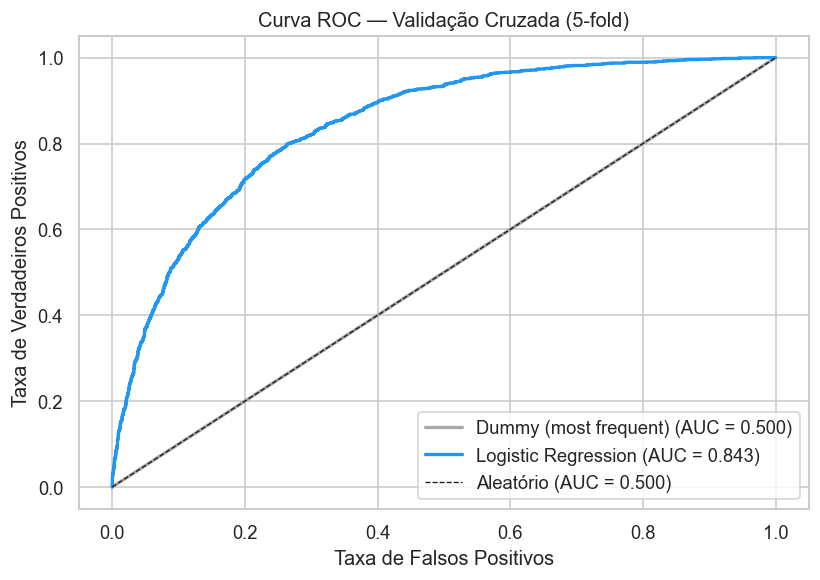

In [5]:
labels = ["Dummy (most frequent)", "Logistic Regression"]
colors = ["#aaaaaa", "#2196F3"]

fig, ax = plt.subplots(figsize=(7, 5))

for r, label, color in zip(results, labels, colors):
    fpr, tpr, _ = roc_curve(y_train_val, r["y_prob"])
    ax.plot(fpr, tpr, label=f"{label} (AUC = {r['auc_roc']:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Aleatório (AUC = 0.500)")
ax.set_xlabel("Taxa de Falsos Positivos")
ax.set_ylabel("Taxa de Verdadeiros Positivos")
ax.set_title("Curva ROC — Validação Cruzada (5-fold)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5. Curvas Precisão-Recall

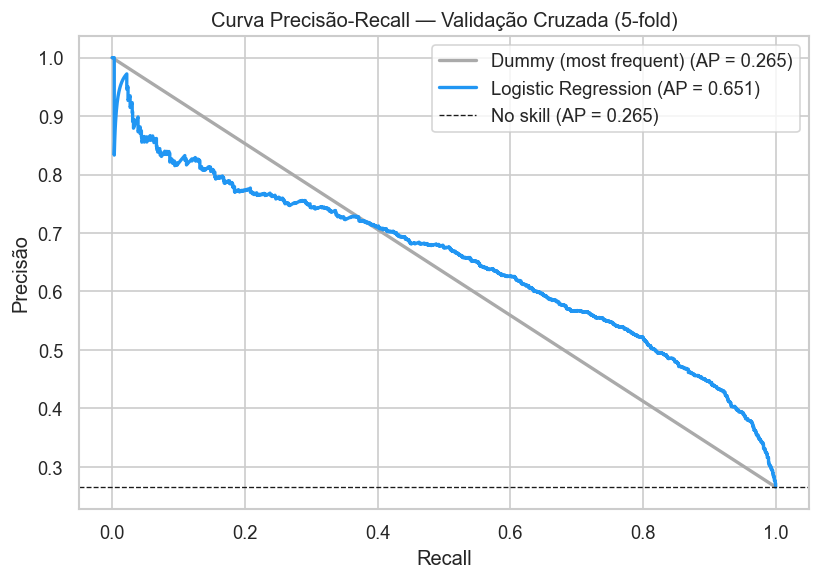

In [6]:
no_skill = y_train_val.mean()

fig, ax = plt.subplots(figsize=(7, 5))

for r, label, color in zip(results, labels, colors):
    prec, rec, _ = precision_recall_curve(y_train_val, r["y_prob"])
    ax.plot(rec, prec, label=f"{label} (AP = {r['pr_auc']:.3f})", color=color, linewidth=2)

ax.axhline(
    no_skill, linestyle="--", color="k", linewidth=0.8,
    label=f"No skill (AP = {no_skill:.3f})"
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precisão")
ax.set_title("Curva Precisão-Recall — Validação Cruzada (5-fold)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 6. Matriz de Confusão — Logistic Regression

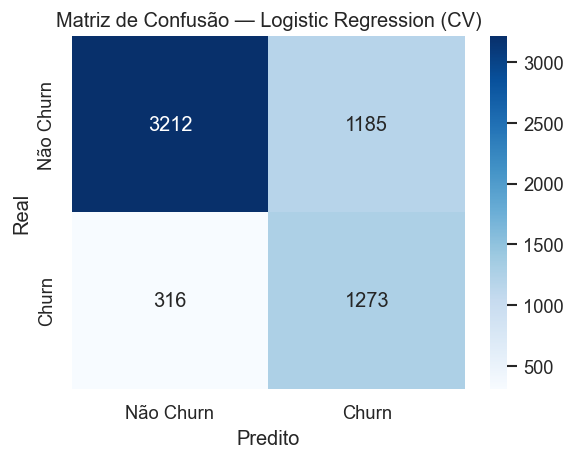

VP: 1273  FN: 316  (recall churn: 80.1%)
FP: 1185  VN: 3212


In [7]:
lr_result = next(r for r in results if r["name"] == "logistic_regression")
y_pred_lr = (lr_result["y_prob"] >= 0.5).astype(int)
cm = confusion_matrix(y_train_val, y_pred_lr)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Não Churn", "Churn"],
    yticklabels=["Não Churn", "Churn"],
    ax=ax,
)
ax.set_ylabel("Real")
ax.set_xlabel("Predito")
ax.set_title("Matriz de Confusão — Logistic Regression (CV)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"VP: {tp}  FN: {fn}  (recall churn: {tp / (tp + fn):.1%})")
print(f"FP: {fp}  VN: {tn}")

## 7. Conclusões

- O `DummyClassifier` confirma o piso: AUC-ROC ≈ 0.50, F1 ≈ 0.0 — qualquer modelo útil precisa superar esses valores.
- A `LogisticRegression` com `class_weight='balanced'` já entrega um desempenho sólido para um modelo linear, servindo como alvo mínimo para a rede neural MLP.
- **Próximo passo:** arquitetura MLP em PyTorch (`notebooks/03_mlp.ipynb`) — o objetivo é superar o AUC-ROC e PR-AUC da regressão logística.

> Experimentos registrados em `mlruns/` (experimento: `telecom-churn-baselines`).  
> Para visualizar: `mlflow ui` na raiz do projeto.